# SDB Module

## Preface

This is a note of how to use SDB module available in [sdb_gui](https://github.com/rifqiharrys/sdb_gui) and data processing based on the SDB GUI workflow.

## Preparation

### Import

In [1]:
# Add sdb module to path
import sys
sys.path.append('../../') # back to sdb_gui root

In [2]:
# Import sdb module
import sdb

### Dataset Information
Prepare your satellite image data and depth sample in a directory and another directory (or not) for the output data. Insert the necessary data information for processing purposes. There are six data identification that is important to the processing. Those are image filename, depth sample filename, depth header name, depth data direction whether it is positive up or down, and header name to differentiate between train and test data and its group name (if any). Type in those values into a suitable key in the dictionary. 

If you have another dataset you want to test, create another dictionary with the same structure and you can easily change between those datasets. It is for this reason that I create a function to administer file location names for input and output and another file tied identification and return it to a dictionary which contain all the necessary information.

In [3]:
# Input and output directory
dir_in = '../data/input/'
dir_out = '../data/output/'

## File information dictionary
# Pulau Karang Bongkok & Pulau Semak Daun
file_1 = {
    'img': 'image.tif',
    'sample': 'depth_sample.shp',
    'depth_header': 'Z_Koreksi',
    'depth_direction': 'down', # positive down
    'split_header': 'note',
    'group': 'train'
}

# Kalimantan Selatan (Pulau Laut)
file_2 = {
    'img': 'kalsel_mosaic_band_stack_raster_crop_2.tif',
    'sample': 'Kalsel_Merge_Pasut.shp',
    'depth_header': 'MSL',
    'depth_direction': 'up', # positive up
    'split_header': 'Note',
    'group': 'train'
}

# Morotai
file_3 = {
    'img': 'sentinel_morotai_4_bands.tif',
    'sample': 'sbes_morotai_sdb.shp',
    'depth_header': 'MSL', # belum dilihat
    'depth_direction': 'down', # positive up
    'split_header': 'Note',
    'group': 'train'
}

def input_metadata(location_dict:dict, input_dir:str, output_dir:str):
    """
    Function to insert all necessary data input metadata based on dictionary structure above.
    This returns to metadata dictionary that will be used in the main script.
    """

    import os
    import pprint

    image_location = f'{input_dir}{location_dict['img']}'
    sample_location = f'{input_dir}{location_dict['sample']}'
    result_location = f'{output_dir}{os.path.splitext(location_dict['img'])[0]}_result'
    depth_header = location_dict['depth_header']
    split_header = location_dict['split_header']
    group = location_dict['group']
    depth_direction = location_dict['depth_direction']

    metadata_dict = {
        'image_location': image_location,
        'sample_location': sample_location,
        'result_location': result_location,
        'depth_header': depth_header,
        'depth_direction': depth_direction,
        'split_header': split_header,
        'group': group
    }

    pprint.pp(metadata_dict)

    return metadata_dict

# Insert metadata dictionary here
input_dict = input_metadata(file_1, dir_in, dir_out) # Change dict name to change input dataset

{'image_location': '../data/input/image.tif',
 'sample_location': '../data/input/depth_sample.shp',
 'result_location': '../data/output/image_result',
 'depth_header': 'Z_Koreksi',
 'depth_direction': 'down',
 'split_header': 'note',
 'group': 'train'}


## Using SDB Module

### Read Data

Reading image data (GeoTIFF).

In [4]:
# Read geotiff
image = sdb.read_geotiff(input_dict['image_location'])
image

<xarray.DataArray (band: 4, y: 192, x: 344)> Size: 1MB
[264192 values with dtype=float32]
Coordinates:
  * band         (band) int64 32B 1 2 3 4
  * y            (y) float64 2kB 9.372e+06 9.372e+06 ... 9.37e+06 9.37e+06
  * x            (x) float64 3kB 6.718e+05 6.718e+05 ... 6.752e+05 6.752e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   0.0001
    add_offset:     0.0

Reading depth sample data (ESRI Shapefile).

In [5]:
# Read shapefile
sample = sdb.read_shapefile(input_dict['sample_location'])
sample

,X,Y,Z_Koreksi,note,geometry
0,674380.385,9366136.610,18.189742,train,POINT Z (674380.385 9366136.61 18.19)
1,674381.454,9366136.741,18.499742,train,POINT Z (674381.454 9366136.741 18.5)
2,674379.467,9366136.949,16.609742,train,POINT Z (674379.467 9366136.949 16.61)
3,674382.322,9366137.317,17.929742,train,POINT Z (674382.322 9366137.317 17.93)
4,674378.929,9366137.442,16.189742,train,POINT Z (674378.929 9366137.442 16.19)
...,...,...,...,...,...
10080,673371.323,9371449.837,1.806161,train,POINT Z (673371.323 9371449.837 1.806)
10081,673368.173,9371449.948,1.606161,train,POINT Z (673368.173 9371449.948 1.606)
10082,673370.582,9371450.079,1.766161,train,POINT Z (673370.582 9371450.079 1.766)
10083,673368.959,9371450.110,1.666161,train,POINT Z (673368.959 9371450.11 1.666)


Show both the satellite image and the depth sample data in an overlap manner. This is to check whether the data is correctly read and the depth sample data is correctly georeferenced. You can also check the depth sample data in a separate plot to see the distribution of the depth values.

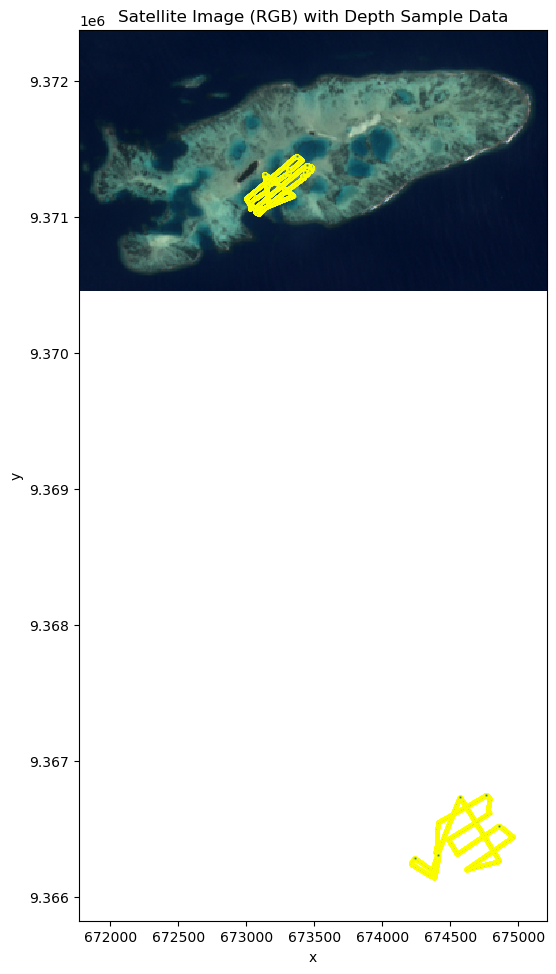

In [6]:
import matplotlib.pyplot as plt

# Select RGB bands (3, 2, 1) and normalize for display
rgb_image = image.isel(band=[2, 1, 0]).transpose('y', 'x', 'band')
rgb_normalized = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min())

# Create figure
fig, ax = plt.subplots(figsize=(12, 10))

# Plot RGB image
rgb_normalized.plot.imshow(ax=ax, rgb='band')

# Overlay sample data points
sample.plot(ax=ax, alpha=0.6, edgecolor='yellow', markersize=5)

ax.set_title('Satellite Image (RGB) with Depth Sample Data')
plt.tight_layout()
plt.show()

### Preprocessing

The `sdb.unravel` function is used to transform the 2D array from each band of the satellite image into a 1D array and stack them together to create a DataFrame with each column representing a band and each row representing a pixel. The `unraveled_image` will be used as the input features for the selected ML model to predict the depth values.

In [7]:
# Unravel image data
unraveled_image = sdb.unravel(image)
unraveled_image

,band_1,band_2,band_3,band_4
0,626.0,385.0,265.0,183.0
1,617.0,383.0,261.0,187.0
2,636.0,383.0,249.0,192.0
3,623.0,378.0,261.0,194.0
4,651.0,393.0,266.0,187.0
...,...,...,...,...
66043,608.0,354.0,242.0,180.0
66044,600.0,345.0,236.0,181.0
66045,595.0,354.0,246.0,178.0
66046,609.0,357.0,247.0,176.0


The `sdb.reproject_vector` function is used to reproject vector data (depth sample) to match the coordinate reference system (CRS) of the imagery data.

In [8]:
# Reproject vector data if it has different CRS with image data
reprojected_sample = sdb.reproject_vector(image, sample)
reprojected_sample

,X,Y,Z_Koreksi,note,geometry
0,674380.385,9366136.610,18.189742,train,POINT Z (674380.385 9366136.61 18.19)
1,674381.454,9366136.741,18.499742,train,POINT Z (674381.454 9366136.741 18.5)
2,674379.467,9366136.949,16.609742,train,POINT Z (674379.467 9366136.949 16.61)
3,674382.322,9366137.317,17.929742,train,POINT Z (674382.322 9366137.317 17.93)
4,674378.929,9366137.442,16.189742,train,POINT Z (674378.929 9366137.442 16.19)
...,...,...,...,...,...
10080,673371.323,9371449.837,1.806161,train,POINT Z (673371.323 9371449.837 1.806)
10081,673368.173,9371449.948,1.606161,train,POINT Z (673368.173 9371449.948 1.606)
10082,673370.582,9371450.079,1.766161,train,POINT Z (673370.582 9371450.079 1.766)
10083,673368.959,9371450.110,1.666161,train,POINT Z (673368.959 9371450.11 1.666)


The `sdb.clip_vector` is a function to remove points that is outside image boundary. This function also use `sdb.reproject_vector` inside so that the vector data CRS matches that of the image data.

In [9]:
# Clip vector that is located outside image boundary
clipped_sample = sdb.clip_vector(image, sample)
clipped_sample

,X,Y,Z_Koreksi,note,geometry
5451,673089.824,9371020.537,10.644119,test,POINT Z (673089.824 9371020.537 10.644)
5452,673090.677,9371020.627,10.654119,test,POINT Z (673090.677 9371020.627 10.654)
5453,673088.900,9371020.741,10.684119,test,POINT Z (673088.9 9371020.741 10.684)
5454,673091.478,9371020.835,10.314119,test,POINT Z (673091.478 9371020.835 10.314)
5455,673092.281,9371021.078,8.904119,test,POINT Z (673092.281 9371021.078 8.904)
...,...,...,...,...,...
10080,673371.323,9371449.837,1.806161,train,POINT Z (673371.323 9371449.837 1.806)
10081,673368.173,9371449.948,1.606161,train,POINT Z (673368.173 9371449.948 1.606)
10082,673370.582,9371450.079,1.766161,train,POINT Z (673370.582 9371450.079 1.766)
10083,673368.959,9371450.110,1.666161,train,POINT Z (673368.959 9371450.11 1.666)


Filtering the depth sample data to the selected depth window (upper_limit and lower_limit). The depth window numbers are based on the positive up direction paradigm. If the depth data is in positive down direction, the depth data will be converted to positive up direction because the rest of the processing is based on positive up direction.

In [10]:
# Filter by depth of input sample data in positive up direction
depth_filtered_sample = sdb.in_depth_filter(
    clipped_sample,
    header=input_dict['depth_header'],
    depth_direction=input_dict['depth_direction']
)
depth_filtered_sample

,X,Y,Z_Koreksi,note,geometry
0,673089.824,9371020.537,-10.644119,test,POINT Z (673089.824 9371020.537 10.644)
1,673090.677,9371020.627,-10.654119,test,POINT Z (673090.677 9371020.627 10.654)
2,673088.900,9371020.741,-10.684119,test,POINT Z (673088.9 9371020.741 10.684)
3,673091.478,9371020.835,-10.314119,test,POINT Z (673091.478 9371020.835 10.314)
4,673092.281,9371021.078,-8.904119,test,POINT Z (673092.281 9371021.078 8.904)
...,...,...,...,...,...
4629,673371.323,9371449.837,-1.806161,train,POINT Z (673371.323 9371449.837 1.806)
4630,673368.173,9371449.948,-1.606161,train,POINT Z (673368.173 9371449.948 1.606)
4631,673370.582,9371450.079,-1.766161,train,POINT Z (673370.582 9371450.079 1.766)
4632,673368.959,9371450.110,-1.666161,train,POINT Z (673368.959 9371450.11 1.666)


Extract features (raster values) from image based on points location and label (depth values) from sample data. Combine corresponding features and label into one dataframe.

In [11]:
# Extract features from image data
features_and_label = sdb.features_label(image, depth_filtered_sample, input_dict['split_header'])
features_and_label

,band_1,band_2,band_3,band_4,x,y,z
0,740.0,507.0,309.0,189.0,673089.824,9371020.537,test
1,725.0,520.0,296.0,200.0,673090.677,9371020.627,test
2,740.0,507.0,309.0,189.0,673088.900,9371020.741,test
3,725.0,520.0,296.0,200.0,673091.478,9371020.835,test
4,725.0,520.0,296.0,200.0,673092.281,9371021.078,test
...,...,...,...,...,...,...,...
4629,1188.0,1213.0,635.0,189.0,673371.323,9371449.837,train
4630,1188.0,1230.0,727.0,187.0,673368.173,9371449.948,train
4631,1154.0,1141.0,578.0,173.0,673370.582,9371450.079,train
4632,1203.0,1196.0,676.0,177.0,673368.959,9371450.110,train


Splitting train and test data randomly is using `train_test_split` function from scikit-learn. While splitting by selected attribute value is using `groupby` function from pandas. Using `sdb.split_data` function to split data randomly or by attribute value by passing split_type argument with value 'random' or 'attribute' respectively.

In [12]:
# Split train and test data randomly
random_f_train, random_f_test, random_z_train, random_z_test = sdb.split_data(
    image,
    depth_filtered_sample,
    depth_header=input_dict['depth_header'],
    split_type='random',
    train_size=0.6
)

In [13]:
# Split train and test data by selected attribute value
selected_f_train, selected_f_test, selected_z_train, selected_z_test = sdb.split_data(
    image,
    depth_filtered_sample,
    depth_header=input_dict['depth_header'],
    split_header=input_dict['split_header'],
    group=input_dict['group']
)

### Depth prediction

Try depth prediction using randomly splitted data.

In [14]:
# Modelling using K-Nearest Neighbors
knn_z_predict, knn_z_validate = sdb.prediction(
    model='knn',
    unraveled_band=unraveled_image,
    features_train=random_f_train.drop(columns=['x', 'y']), #excluding xy coordinates
    label_train=random_z_train,
)
knn_z_predict

array([-9.902119, -9.902119, -9.902119, ..., -9.902119, -9.902119,
       -9.902119], shape=(66048,))

In [15]:
# Modelling using Multiple Linear Regression
mlr_z_predict, mlr_z_validate = sdb.prediction(
    model='mlr',
    unraveled_band=unraveled_image,
    features_train=random_f_train.drop(columns=['x', 'y']), #excluding xy coordinates
    label_train=random_z_train,
)
mlr_z_predict

array([-7.23853968, -6.93729224, -7.436141  , ..., -7.11043368,
       -7.50513441, -7.05264   ], shape=(66048,))

In [16]:
# Modelling using Random Forest
rf_z_predict, rf_z_validate = sdb.prediction(
    model='rf',
    unraveled_band=unraveled_image,
    features_train=random_f_train.drop(columns=['x', 'y']), #excluding xy coordinates
    label_train=random_z_train,
)
rf_z_predict

array([-9.79752903, -9.79752903, -9.86941408, ..., -9.79752903,
       -9.79752903, -9.79752903], shape=(66048,))

### Post Processing

Filter prediction output based on depth if you want the output to be in a certain range. Default value is 0 to -12. However, I will not use the depth filtered output in the next step.

In [17]:
# Filter prediction output based on depth (default 0 to -12)
depth_filtered_z_predict = sdb.out_depth_filter(mlr_z_predict) #trying this function using prediction output of MLR
depth_filtered_z_predict

array([-7.23853968, -6.93729224, -7.436141  , ..., -7.11043368,
       -7.50513441, -7.05264   ], shape=(66048,))

To evaluate depth prediction result, we need to have the test data containing depth information (`z_test`) and depth prediction data at the same location. To do so, we need to reshape depth prediction data to image shape and create new dataarray from reshaped depth prediction data and do a point sampling using test data xy coordinates.

In [18]:
# Reshape predicted depth array to image shape
rf_az_predict = sdb.reshape_prediction(
    rf_z_predict,
    image
)
rf_az_predict

array([[-9.79752903, -9.79752903, -9.86941408, ..., -9.79752903,
        -9.79752903, -9.79752903],
       [-9.79752903, -9.79752903, -9.79752903, ..., -9.79752903,
        -9.86941408, -9.79752903],
       [-9.79752903, -9.86941408, -9.79752903, ..., -9.79752903,
        -9.79752903, -9.79752903],
       ...,
       [-9.87391986, -9.87391986, -9.87391986, ..., -9.79752903,
        -9.79752903, -9.79752903],
       [-9.79752903, -9.88556715, -9.78600384, ..., -9.79752903,
        -9.79752903, -9.79752903],
       [-9.78600384, -9.78600384, -9.78600384, ..., -9.79752903,
        -9.79752903, -9.79752903]], shape=(192, 344))

In [19]:
# Create new dataarray from predicted depth array with the same coordinate as the image
rf_daz_predict = sdb.array_to_dataarray(
    rf_az_predict,
    image
)
rf_daz_predict

<xarray.DataArray (band: 1, y: 192, x: 344)> Size: 528kB
array([[[-9.79752903, -9.79752903, -9.86941408, ..., -9.79752903,
         -9.79752903, -9.79752903],
        [-9.79752903, -9.79752903, -9.79752903, ..., -9.79752903,
         -9.86941408, -9.79752903],
        [-9.79752903, -9.86941408, -9.79752903, ..., -9.79752903,
         -9.79752903, -9.79752903],
        ...,
        [-9.87391986, -9.87391986, -9.87391986, ..., -9.79752903,
         -9.79752903, -9.79752903],
        [-9.79752903, -9.88556715, -9.78600384, ..., -9.79752903,
         -9.79752903, -9.79752903],
        [-9.78600384, -9.78600384, -9.78600384, ..., -9.79752903,
         -9.79752903, -9.79752903]]], shape=(1, 192, 344))
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 2kB 9.372e+06 9.372e+06 ... 9.37e+06 9.37e+06
  * x            (x) float64 3kB 6.718e+05 6.718e+05 ... 6.752e+05 6.752e+05
    spatial_ref  int64 8B 0

In [20]:
# Point sampling predicted depth using test data points location
rf_dfz_predict = sdb.point_sampling(
    rf_daz_predict,
    x=random_f_test.x,
    y=random_f_test.y,
    include_xy=False
)
rf_dfz_predict

,band_1
0,-6.668066
1,-2.177833
2,-1.020520
3,-2.619685
4,-9.995009
...,...
1849,-9.995009
1850,-3.286398
1851,-2.421394
1852,-0.902781


In [21]:
# Calculate RMSE, MAE, and R squared value
metrics = sdb.evaluate(
    true_val=random_z_test,
    pred_val=rf_dfz_predict['band_1']
)

print(f'RMSE:\t {round(metrics.rmse, 3)}')
print(f'MAE:\t {round(metrics.mae, 3)}')
print(f'R\u00B2:\t {round(metrics.r2, 3)}')

RMSE:	 0.32
MAE:	 0.179
R²:	 0.978


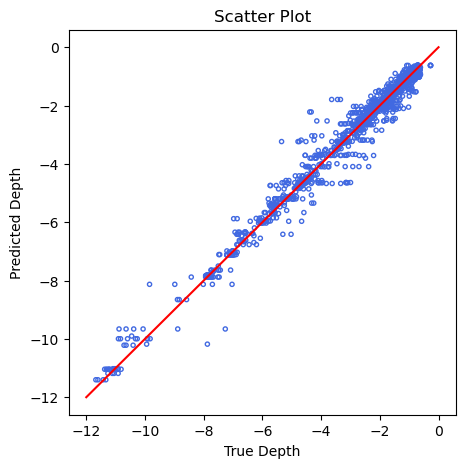

In [22]:
# Create scatter plotter
fig, ax = sdb.scatter_plotter(
    true_val=random_z_test,
    pred_val=rf_dfz_predict['band_1']
)

In [23]:
# Applying median filter with the size of 3 to the predicted depth array
rf_az_predict_median = sdb.median_filter(
    rf_daz_predict.values[0],
    filter_size=5
)

In [24]:
# Assign new median filtered array to a dataarray with the same coordinate as the image
rf_daz_predict_median = sdb.array_to_dataarray(
    rf_az_predict_median,
    image
)
rf_daz_predict_median

<xarray.DataArray (band: 1, y: 192, x: 344)> Size: 528kB
array([[[-9.79752903, -9.79752903, -9.79752903, ..., -9.79752903,
         -9.79752903, -9.79752903],
        [-9.79752903, -9.79752903, -9.79752903, ..., -9.79752903,
         -9.79752903, -9.79752903],
        [-9.79752903, -9.79752903, -9.79752903, ..., -9.79752903,
         -9.79752903, -9.79752903],
        ...,
        [-9.86941408, -9.86941408, -9.86941408, ..., -9.79752903,
         -9.79752903, -9.79752903],
        [-9.79752903, -9.86941408, -9.79752903, ..., -9.79752903,
         -9.79752903, -9.79752903],
        [-9.79752903, -9.79752903, -9.79752903, ..., -9.79752903,
         -9.79752903, -9.79752903]]], shape=(1, 192, 344))
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 2kB 9.372e+06 9.372e+06 ... 9.37e+06 9.37e+06
  * x            (x) float64 3kB 6.718e+05 6.718e+05 ... 6.752e+05 6.752e+05
    spatial_ref  int64 8B 0

### Write Data

In [25]:
# Save median filtered depth prediction to Geotiff
sdb.write_geotiff(
    rf_daz_predict_median,
    f'{input_dict['result_location']}_dem.tif'
)

Raster data saved to ../data/output/image_result_dem.tif


Add test data, both features and label into one dataframe. Also add the prediction output before median filtering and then save it to shapefile.

In [26]:
# Create dataframe containing train data
df_train = random_f_train.copy()
df_train['z'] = random_z_train.copy()
df_train

,band_1,band_2,band_3,band_4,x,y,z
0,981.0,860.0,375.0,189.0,673022.470,9371096.158,-3.962304
1,1374.0,1527.0,1168.0,269.0,673312.847,9371329.124,-1.006773
2,879.0,718.0,366.0,189.0,673186.449,9371092.555,-2.270746
3,1280.0,1396.0,994.0,229.0,673301.195,9371268.829,-0.753955
4,928.0,808.0,368.0,188.0,673135.651,9371071.623,-3.430746
...,...,...,...,...,...,...,...
2775,1364.0,1494.0,1134.0,284.0,673308.157,9371400.218,-0.936161
2776,919.0,754.0,337.0,187.0,673152.991,9371083.189,-4.017473
2777,976.0,1043.0,797.0,258.0,673411.338,9371299.073,-0.650809
2778,1056.0,941.0,383.0,190.0,673226.437,9371330.813,-3.476161


In [27]:
# Create dataframe containing test data
df_test = random_f_test.copy()
df_test['z'] = random_z_test.copy()
df_test['z_predict'] = rf_dfz_predict['band_1'].copy()
df_test

,band_1,band_2,band_3,band_4,x,y,z,z_predict
0,886.0,677.0,316.0,200.0,673118.681,9371113.807,-6.617191,-6.668066
1,1286.0,1260.0,551.0,171.0,673295.281,9371196.711,-2.247357,-2.177833
2,1263.0,1388.0,1053.0,260.0,673432.889,9371324.574,-1.097422,-1.020520
3,1151.0,1071.0,447.0,176.0,673160.018,9371275.044,-2.649245,-2.619685
4,725.0,520.0,296.0,200.0,673096.257,9371029.266,-10.264119,-9.995009
...,...,...,...,...,...,...,...,...
1849,725.0,520.0,296.0,200.0,673095.872,9371028.746,-10.594119,-9.995009
1850,1077.0,976.0,391.0,180.0,673207.358,9371314.806,-3.379245,-3.286398
1851,1243.0,1162.0,471.0,178.0,673140.930,9371246.696,-2.303953,-2.421394
1852,1302.0,1420.0,1079.0,269.0,673437.041,9371331.183,-0.674126,-0.902781


In [28]:
# Save train and test data to shapefile
train_test_dict = {
    'train': df_train,
    'test': df_test
}

for key, value in train_test_dict.items():
    sdb.write_shapefile(
        value,
        f'{input_dict['result_location']}_{key}.shp',
        x_col_name='x',
        y_col_name='y',
        crs=depth_filtered_sample.crs
    )

Vector data saved to ../data/output/image_result_train.shp
Vector data saved to ../data/output/image_result_test.shp
